# N7b — Embedding Model Ablation

Systematic experiment across embedding models and pooling strategies.
Evaluates each combination on MdAPE (ln(EV/Sales), k=10) and FF49 hit rate.

**Models tested:**
| ID | Model | Dim | Pooling |
|----|-------|-----|---------|
| M2a | ProsusAI/finbert | 768 | CLS (baseline) |
| M2b | ProsusAI/finbert | 768 | Mean |
| M2c | ProsusAI/finbert | 768 | Max |
| M2d | yiyanghkust/finbert-tone | 768 | CLS |
| M2e | yiyanghkust/finbert-tone | 768 | Mean |
| M2f | sentence-transformers/all-mpnet-base-v2 | 768 | Mean (native) |
| M2g | sentence-transformers/all-MiniLM-L6-v2 | 384 | Mean (native) |
| M2h | sentence-transformers/paraphrase-multilingual-mpnet-base-v2 | 768 | Mean (native) |

**Output:** Ablation table + figures saved to `figures/ablation_*.pdf`


In [3]:
# Cell 1 — install & imports
import subprocess, sys
for pkg in ['torch', 'transformers', 'sentence-transformers', 'scikit-learn', 'sentencepiece']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '-q'], check=True)

# Force reimport of transformers after sentencepiece is now present
import importlib
import transformers
importlib.reload(transformers)

import sys; sys.path.insert(0, '..')
from config import *
import pandas as pd
import numpy as np
import torch
import json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from transformers import AutoTokenizer, AutoModel
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import warnings
warnings.filterwarnings('ignore')

np.random.seed(RANDOM_SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
print(f"Config loaded.")
print(f"  SUMMARIES_DIR : {SUMMARIES_DIR}")
print(f"  FIGURES       : {FIGURES}")

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
    'axes.grid': True, 'grid.color': '#e5e5e5',
    'font.family': 'serif', 'font.size': 10,
    'savefig.dpi': FIGURE_DPI, 'savefig.bbox': 'tight',
    'savefig.facecolor': 'white',
})


Device: cpu
Config loaded.
  SUMMARIES_DIR : /work/Repo/notebooks/../data/processed/Business_Summaries
  FIGURES       : /work/Repo/notebooks/../figures


In [4]:
import subprocess, sys
result = subprocess.run([sys.executable, '-m', 'pip', 'show', 'sentencepiece'], 
                        capture_output=True, text=True)
print(result.stdout)
print(sys.executable)

Name: sentencepiece
Version: 0.2.1
Summary: Unsupervised text tokenizer and detokenizer.
Home-page: https://github.com/google/sentencepiece
Author: 
Author-email: Taku Kudo <taku@google.com>
License: 
Location: /opt/conda/lib/python3.12/site-packages
Requires: 
Required-by: 

/opt/conda/bin/python


In [5]:
# Cell 2 — declare I/O
INPUTS  = list(SUMMARIES_FILES.values()) + [PEERS_M0, MULTIPLES, PANEL_CLEAN]
OUTPUTS = [FIGURES / 'ablation_mdape.pdf',
           FIGURES / 'ablation_hitrate.pdf',
           DATA_RESULTS / 'ablation_results.csv']
# PURPOSE : Full embedding model ablation — model × pooling → MdAPE + FF49 hit rate
# RUNTIME : ~45 min GPU (all 8 configurations)
# DEPENDS : business_summaries_{year}.csv (N3), peers_m0.parquet (N5)


## 1. Load Summaries & Panel

In [6]:
# Cell 3 — load summaries (evaluation sample)
INVALID_FLAGS = {'ERROR', 'INSUFFICIENT_DATA', 'ERROR_EXTRACTING_TEXT'}

frames = []
for yr in YEARS:
    path = SUMMARIES_FILES[yr]
    if not path.exists():
        print(f"  {yr}: NOT FOUND")
        continue
    df_s = pd.read_csv(path)
    df_s = df_s[
        df_s['business_description'].notna() &
        ~df_s['business_description'].isin(INVALID_FLAGS) &
        (df_s['business_description'].str.len() > 50)
    ].copy()
    df_s['fyear'] = yr
    frames.append(df_s[['tic', 'fyear', 'business_description']])
    print(f"  {yr}: {len(df_s):,} valid summaries")

df_text = pd.concat(frames, ignore_index=True)
print(f"\nTotal: {len(df_text):,} firm-year summaries")

# Load support data
multiples  = pd.read_parquet(MULTIPLES)
peers_m0   = pd.read_parquet(PEERS_M0).dropna(subset=['focal_tic','peer_tic'])
df_panel   = pd.read_parquet(PANEL_CLEAN,
    columns=['tic','fyear','ff49_num','industry'])
df_industry = df_panel[['tic','fyear','ff49_num']].drop_duplicates()

# Evaluation sample — firms with valid summaries
eval_set = set(zip(df_text['tic'], df_text['fyear'].astype(int)))
print(f"Evaluation sample: {len(eval_set):,} firm-years")


  2020: 2,446 valid summaries
  2021: 2,781 valid summaries
  2022: 2,717 valid summaries
  2023: 2,742 valid summaries
  2024: 2,873 valid summaries

Total: 13,559 firm-year summaries
Evaluation sample: 13,559 firm-years


## 2. Embedding Configurations

In [5]:
# Cell 4 — define all embedding configurations
CONFIGS = [
    {
        'id'         : 'M2a',
        'label'      : 'FinBERT / CLS (baseline)',
        'model_name' : 'ProsusAI/finbert',
        'model_type' : 'hf',          # huggingface AutoModel
        'pooling'    : 'cls',
        'dim'        : 768,
    },
    {
        'id'         : 'M2b',
        'label'      : 'FinBERT / Mean',
        'model_name' : 'ProsusAI/finbert',
        'model_type' : 'hf',
        'pooling'    : 'mean',
        'dim'        : 768,
    },
    {
        'id'         : 'M2c',
        'label'      : 'FinBERT / Max',
        'model_name' : 'ProsusAI/finbert',
        'model_type' : 'hf',
        'pooling'    : 'max',
        'dim'        : 768,
    },
    {
        'id'         : 'M2d',
        'label'      : 'FinBERT-Tone / CLS',
        'model_name' : 'yiyanghkust/finbert-tone',
        'model_type' : 'hf',
        'pooling'    : 'cls',
        'dim'        : 768,
    },
    {
        'id'         : 'M2e',
        'label'      : 'FinBERT-Tone / Mean',
        'model_name' : 'yiyanghkust/finbert-tone',
        'model_type' : 'hf',
        'pooling'    : 'mean',
        'dim'        : 768,
    },
    {
        'id'         : 'M2f',
        'label'      : 'all-mpnet-base-v2 / Mean',
        'model_name' : 'sentence-transformers/all-mpnet-base-v2',
        'model_type' : 'st',          # sentence-transformers
        'pooling'    : 'mean',        # native ST pooling
        'dim'        : 768,
    },
    {
        'id'         : 'M2g',
        'label'      : 'all-MiniLM-L6-v2 / Mean',
        'model_name' : 'sentence-transformers/all-MiniLM-L6-v2',
        'model_type' : 'st',
        'pooling'    : 'mean',
        'dim'        : 384,
    },
    {
        'id'         : 'M2h',
        'label'      : 'paraphrase-multilingual / Mean',
        'model_name' : 'sentence-transformers/paraphrase-multilingual-mpnet-base-v2',
        'model_type' : 'st',
        'pooling'    : 'mean',
        'dim'        : 768,
    },
]

print(f"Configurations defined: {len(CONFIGS)}")
for cfg in CONFIGS:
    print(f"  {cfg['id']:<5} {cfg['label']:<40} dim={cfg['dim']}")


Configurations defined: 8
  M2a   FinBERT / CLS (baseline)                 dim=768
  M2b   FinBERT / Mean                           dim=768
  M2c   FinBERT / Max                            dim=768
  M2d   FinBERT-Tone / CLS                       dim=768
  M2e   FinBERT-Tone / Mean                      dim=768
  M2f   all-mpnet-base-v2 / Mean                 dim=768
  M2g   all-MiniLM-L6-v2 / Mean                  dim=384
  M2h   paraphrase-multilingual / Mean           dim=768


## 3. Embedding Functions

In [10]:
# Cell 5 — embedding functions for HF and ST models
BATCH_SIZE = 64
def embed_hf(texts, model_name, pooling, device, batch_size=BATCH_SIZE):
    """Embed with HuggingFace AutoModel — supports CLS, mean, max pooling."""
    from transformers import BertTokenizer, BertModel
    tokenizer = BertTokenizer.from_pretrained(model_name)
    model     = BertModel.from_pretrained(model_name, ignore_mismatched_sizes=True).to(device)
    model.eval()
    all_embs = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc   = tokenizer(batch, max_length=512, truncation=True,
                          padding=True, return_tensors='pt').to(device)
        with torch.no_grad():
            out = model(**enc)
        hidden = out.last_hidden_state   # (batch, seq, dim)
        mask   = enc['attention_mask'].unsqueeze(-1).float()
        if pooling == 'cls':
            emb = hidden[:, 0, :]
        elif pooling == 'mean':
            emb = (hidden * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        elif pooling == 'max':
            hidden_masked = hidden.masked_fill(mask == 0, -1e9)
            emb = hidden_masked.max(dim=1).values
        all_embs.append(emb.cpu().numpy())
    del model
    torch.cuda.empty_cache() if device == 'cuda' else None
    embs  = np.vstack(all_embs)
    norms = np.linalg.norm(embs, axis=1, keepdims=True)
    return embs / np.where(norms == 0, 1, norms)
def embed_st(texts, model_name, device, batch_size=BATCH_SIZE):
    """Embed with SentenceTransformer (native mean pooling + normalisation)."""
    model = SentenceTransformer(model_name, device=device)
    embs  = model.encode(texts, batch_size=batch_size,
                         normalize_embeddings=True,
                         show_progress_bar=False)
    del model
    torch.cuda.empty_cache() if device == 'cuda' else None
    return embs
print("Embedding functions defined.")
print(f"  embed_hf() — HuggingFace AutoModel (CLS / mean / max pooling)")
print(f"  embed_st() — SentenceTransformer (native mean pooling)")

Embedding functions defined.
  embed_hf() — HuggingFace AutoModel (CLS / mean / max pooling)
  embed_st() — SentenceTransformer (native mean pooling)


## 4. Evaluation Functions

In [7]:
# Cell 6 — kNN peer list + MdAPE + FF49 hit rate
def build_peers(df_year, emb_cols_or_arr, fyear, k_max=20):
    """Build peer list from embedding array for one year."""
    tickers = df_year['tic'].values
    if isinstance(emb_cols_or_arr, np.ndarray):
        E = emb_cols_or_arr
    else:
        E = df_year[emb_cols_or_arr].values

    sim = cosine_similarity(E)
    np.fill_diagonal(sim, -np.inf)

    records = []
    k = min(k_max, len(tickers)-1)
    for i in range(len(tickers)):
        top_idx = np.argpartition(sim[i], -k)[-k:]
        top_idx = top_idx[np.argsort(sim[i][top_idx])[::-1]]
        for rank, j in enumerate(top_idx, 1):
            records.append({
                'focal_tic'       : tickers[i],
                'focal_fyear'     : fyear,
                'peer_tic'        : tickers[j],
                'rank'            : rank,
                'similarity_score': float(sim[i][j]),
                'model'           : 'M2_ablation',
            })
    return pd.DataFrame(records)


def compute_mdape(peers_df, multiples_df, mult_col, k, eval_set):
    if peers_df['rank'].max() > 1:
        peers_k = peers_df[peers_df['rank'] <= k].copy()
    else:
        peers_k = peers_df.copy()

    # Restrict to evaluation sample focal firms
    peers_k = peers_k[peers_k.apply(
        lambda r: (r['focal_tic'], int(r['focal_fyear'])) in eval_set, axis=1
    )]

    mult_lookup = multiples_df[['tic','fyear',mult_col]].dropna(subset=[mult_col])
    peers_k = peers_k.merge(
        mult_lookup.rename(columns={'tic':'peer_tic','fyear':'focal_fyear',
                                    mult_col:'peer_multiple'}),
        on=['peer_tic','focal_fyear'], how='inner'
    )
    predicted = (peers_k.groupby(['focal_tic','focal_fyear'])['peer_multiple']
                         .median().reset_index()
                         .rename(columns={'peer_multiple':'predicted'}))
    predicted = predicted.merge(
        mult_lookup.rename(columns={'tic':'focal_tic','fyear':'focal_fyear',
                                    mult_col:'actual'}),
        on=['focal_tic','focal_fyear'], how='inner'
    )
    predicted['ape'] = ((predicted['actual'] - predicted['predicted']).abs() /
                         predicted['actual'].abs())
    errors = predicted['ape'].dropna().values

    rng   = np.random.RandomState(RANDOM_SEED)
    boots = [np.median(rng.choice(errors, len(errors), replace=True))
             for _ in range(500)]
    return {
        'mdape': np.median(errors),
        'ci_lo': np.percentile(boots, 2.5),
        'ci_hi': np.percentile(boots, 97.5),
        'n'    : len(errors),
    }


def compute_hit_rate(peers_df, df_industry, k):
    if peers_df['rank'].max() > 1:
        peers_k = peers_df[peers_df['rank'] <= k].copy()
    else:
        peers_k = peers_df.copy()

    peers_k = peers_k.merge(
        df_industry.rename(columns={'tic':'focal_tic','fyear':'focal_fyear',
                                    'ff49_num':'focal_ff49'}),
        on=['focal_tic','focal_fyear'], how='left'
    )
    peers_k = peers_k.merge(
        df_industry.rename(columns={'tic':'peer_tic','fyear':'focal_fyear',
                                    'ff49_num':'peer_ff49'}),
        on=['peer_tic','focal_fyear'], how='left'
    )
    peers_k['same'] = peers_k['focal_ff49'] == peers_k['peer_ff49']
    return peers_k.groupby(['focal_tic','focal_fyear'])['same'].mean().mean() * 100


print("Evaluation functions defined.")


Evaluation functions defined.


## 5. Run Full Ablation

In [12]:
# Cell 7 — run all configurations (checkpointed per config)
K_EVAL    = K_MAIN   # k=10 for primary evaluation
K_MAX_EMB = 20       # store up to k=20 for sensitivity

ablation_results = []
ABLATION_DIR = DATA_PROC / "ablation_embeddings"
ABLATION_DIR.mkdir(parents=True, exist_ok=True)

for cfg in CONFIGS:
    cfg_id    = cfg['id']
    label     = cfg['label']
    checkpoint = ABLATION_DIR / f"peers_{cfg_id}.parquet"

    print(f"\n{'='*65}")
    print(f"{cfg_id}: {label}")
    print(f"{'='*65}")

    # ── Load or compute peer lists ────────────────────────────────────────────
    if checkpoint.exists():
        print(f"  Checkpoint found — loading peers")
        peers_cfg = pd.read_parquet(checkpoint)
    else:
        print(f"  Embedding {len(df_text):,} summaries...")
        texts = df_text['business_description'].tolist()

        if cfg['model_type'] == 'hf':
            embs = embed_hf(texts, cfg['model_name'], cfg['pooling'], device)
        else:
            embs = embed_st(texts, cfg['model_name'], device)

        print(f"  Embeddings shape: {embs.shape} | L2 norm check: {np.linalg.norm(embs, axis=1).mean():.4f}")

        # Build per-year peer lists
        all_peers = []
        for yr in YEARS:
            mask   = df_text['fyear'] == yr
            df_yr  = df_text[mask].reset_index(drop=True)
            embs_yr = embs[mask.values]
            if len(df_yr) < 2:
                continue
            peers_yr = build_peers(df_yr, embs_yr, yr, k_max=K_MAX_EMB)
            all_peers.append(peers_yr)
            print(f"    {yr}: {len(df_yr):,} firms → {len(peers_yr):,} peer records")

        peers_cfg = pd.concat(all_peers, ignore_index=True)
        peers_cfg.to_parquet(checkpoint, index=False)
        print(f"  Saved checkpoint: {checkpoint.name}")

    # ── Evaluate ──────────────────────────────────────────────────────────────
    mdape_result = compute_mdape(peers_cfg, multiples, 'ln_v2s', K_EVAL, eval_set)
    hit_rate     = compute_hit_rate(peers_cfg, df_industry, K_EVAL)
    avg_top1_sim = peers_cfg[peers_cfg['rank']==1]['similarity_score'].mean()

    result = {
        'config_id'   : cfg_id,
        'label'       : label,
        'model_name'  : cfg['model_name'],
        'pooling'     : cfg['pooling'],
        'dim'         : cfg['dim'],
        'mdape'       : mdape_result['mdape'],
        'ci_lo'       : mdape_result['ci_lo'],
        'ci_hi'       : mdape_result['ci_hi'],
        'n'           : mdape_result['n'],
        'hit_rate_pct': hit_rate,
        'avg_top1_sim': avg_top1_sim,
    }
    ablation_results.append(result)

    print(f"  MdAPE     : {result['mdape']*100:.2f}% [{result['ci_lo']*100:.2f}%, {result['ci_hi']*100:.2f}%]")
    print(f"  Hit rate  : {hit_rate:.1f}%")
    print(f"  Avg sim   : {avg_top1_sim:.4f}")

abl_df = pd.DataFrame(ablation_results).sort_values('mdape')
print(f"\nAll configurations complete.")



M2a: FinBERT / CLS (baseline)
  Checkpoint found — loading peers
  MdAPE     : 57.81% [56.63%, 59.21%]
  Hit rate  : 36.4%
  Avg sim   : 0.9769

M2b: FinBERT / Mean
  Checkpoint found — loading peers
  MdAPE     : 52.08% [51.00%, 53.20%]
  Hit rate  : 55.6%
  Avg sim   : 0.9815

M2c: FinBERT / Max
  Checkpoint found — loading peers
  MdAPE     : 53.49% [51.93%, 54.78%]
  Hit rate  : 53.3%
  Avg sim   : 0.9833

M2d: FinBERT-Tone / CLS
  Embedding 13,534 summaries...


vocab.txt: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/439M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: yiyanghkust/finbert-tone
Key                          | Status     |  | 
-----------------------------+------------+--+-
classifier.weight            | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 
classifier.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

  Embeddings shape: (13534, 768) | L2 norm check: 1.0000
    2020: 2,441 firms → 48,820 peer records
    2021: 2,777 firms → 55,540 peer records
    2022: 2,710 firms → 54,200 peer records
    2023: 2,737 firms → 54,740 peer records
    2024: 2,869 firms → 57,380 peer records
  Saved checkpoint: peers_M2h.parquet
  MdAPE     : 58.07% [57.06%, 59.43%]
  Hit rate  : 45.3%
  Avg sim   : 0.7215

All configurations complete.


## 6. Results Table

In [12]:
# Reload ablation results from checkpointed peer files
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity

ABLATION_DIR = DATA_PROC / "ablation_embeddings"

CONFIGS_LABELS = {
    'M2a': 'FinBERT / CLS (baseline)',
    'M2b': 'FinBERT / Mean',
    'M2c': 'FinBERT / Max',
    'M2d': 'FinBERT-Tone / CLS',
    'M2e': 'FinBERT-Tone / Mean',
    'M2f': 'all-mpnet-base-v2 / Mean',
    'M2g': 'all-MiniLM-L6-v2 / Mean',
    'M2h': 'paraphrase-multilingual / Mean',
}

# Hardcode results from the previous run output
ablation_results = [
    {'config_id': 'M2a', 'label': 'FinBERT / CLS (baseline)',         'mdape': 0.5781, 'ci_lo': 0.5663, 'ci_hi': 0.5921, 'hit_rate_pct': 36.4, 'avg_top1_sim': 0.9769},
    {'config_id': 'M2b', 'label': 'FinBERT / Mean',                   'mdape': 0.5208, 'ci_lo': 0.5100, 'ci_hi': 0.5320, 'hit_rate_pct': 55.6, 'avg_top1_sim': 0.9815},
    {'config_id': 'M2c', 'label': 'FinBERT / Max',                    'mdape': 0.5349, 'ci_lo': 0.5193, 'ci_hi': 0.5478, 'hit_rate_pct': 53.3, 'avg_top1_sim': 0.9833},
    {'config_id': 'M2d', 'label': 'FinBERT-Tone / CLS',               'mdape': 0.5618, 'ci_lo': 0.5474, 'ci_hi': 0.5752, 'hit_rate_pct': 43.3, 'avg_top1_sim': 0.9647},
    {'config_id': 'M2e', 'label': 'FinBERT-Tone / Mean',              'mdape': 0.5375, 'ci_lo': 0.5263, 'ci_hi': 0.5493, 'hit_rate_pct': 52.9, 'avg_top1_sim': 0.9641},
    {'config_id': 'M2f', 'label': 'all-mpnet-base-v2 / Mean',         'mdape': 0.5267, 'ci_lo': 0.5144, 'ci_hi': 0.5375, 'hit_rate_pct': 59.5, 'avg_top1_sim': 0.7608},
    {'config_id': 'M2g', 'label': 'all-MiniLM-L6-v2 / Mean',         'mdape': 0.5395, 'ci_lo': 0.5279, 'ci_hi': 0.5534, 'hit_rate_pct': 56.0, 'avg_top1_sim': 0.6734},
    {'config_id': 'M2h', 'label': 'paraphrase-multilingual / Mean',   'mdape': 0.5807, 'ci_lo': 0.5706, 'ci_hi': 0.5943, 'hit_rate_pct': 45.3, 'avg_top1_sim': 0.7215},
]

abl_df = pd.DataFrame(ablation_results).sort_values('mdape').reset_index(drop=True)
print(f"Loaded {len(abl_df)} ablation configurations from previous run.")
print(f"Best: {abl_df.iloc[0]['config_id']} — {abl_df.iloc[0]['label']} ({abl_df.iloc[0]['mdape']*100:.2f}%)")

Loaded 8 ablation configurations from previous run.
Best: M2b — FinBERT / Mean (52.08%)


In [13]:
abl_df = pd.DataFrame(ablation_results).sort_values('mdape')
ablation_results = abl_df.to_dict(orient='records')
# Cell 8 — print ablation results table
print("=" * 85)
print("EMBEDDING ABLATION RESULTS — ln(EV/Sales), k=10")
print("=" * 85)
print(f"{'ID':<5} {'Configuration':<42} {'MdAPE':>8} {'95% CI':>20} {'Hit%':>6} {'Sim':>7}")
print("-" * 85)

# Baseline numbers from main pipeline (N10, n=13,559 evaluation sample)
baseline_rows = [
    {'config_id': 'M0',  'label': 'FF49 Baseline (reference)',
     'mdape': 0.5479, 'ci_lo': 0.5350, 'ci_hi': 0.5620,
     'hit_rate_pct': 100.0, 'avg_top1_sim': 1.0},
    {'config_id': 'M1',  'label': 'Financial kNN (reference)',
     'mdape': 0.4375, 'ci_lo': 0.4257, 'ci_hi': 0.4457,
     'hit_rate_pct': 35.4, 'avg_top1_sim': None},
]

print("  --- Baselines ---")
for row in baseline_rows:
    sim_str = f"{row['avg_top1_sim']:.4f}" if row['avg_top1_sim'] else "  —   "
    print(f"  {row['config_id']:<5} {row['label']:<42} "
          f"{row['mdape']*100:>7.2f}%  "
          f"[{row['ci_lo']*100:.2f}%, {row['ci_hi']*100:.2f}%]  "
          f"{row['hit_rate_pct']:>5.1f}%  {sim_str}")

print("  --- Text Embedding Ablation ---")
for _, row in abl_df.iterrows():
    best = "◄ BEST" if row['config_id'] == abl_df.iloc[0]['config_id'] else ""
    print(f"  {row['config_id']:<5} {row['label']:<42} "
          f"{row['mdape']*100:>7.2f}%  "
          f"[{row['ci_lo']*100:.2f}%, {row['ci_hi']*100:.2f}%]  "
          f"{row['hit_rate_pct']:>5.1f}%  "
          f"{row['avg_top1_sim']:>6.4f}  {best}")


EMBEDDING ABLATION RESULTS — ln(EV/Sales), k=10
ID    Configuration                                 MdAPE               95% CI   Hit%     Sim
-------------------------------------------------------------------------------------
  --- Baselines ---
  M0    FF49 Baseline (reference)                    54.79%  [53.50%, 56.20%]  100.0%  1.0000
  M1    Financial kNN (reference)                    43.75%  [42.57%, 44.57%]   35.4%    —   
  --- Text Embedding Ablation ---
  M2b   FinBERT / Mean                               52.08%  [51.00%, 53.20%]   55.6%  0.9815  ◄ BEST
  M2f   all-mpnet-base-v2 / Mean                     52.67%  [51.44%, 53.75%]   59.5%  0.7608  
  M2c   FinBERT / Max                                53.49%  [51.93%, 54.78%]   53.3%  0.9833  
  M2e   FinBERT-Tone / Mean                          53.75%  [52.63%, 54.93%]   52.9%  0.9641  
  M2g   all-MiniLM-L6-v2 / Mean                      53.95%  [52.79%, 55.34%]   56.0%  0.6734  
  M2d   FinBERT-Tone / CLS                  

## 7. Figures

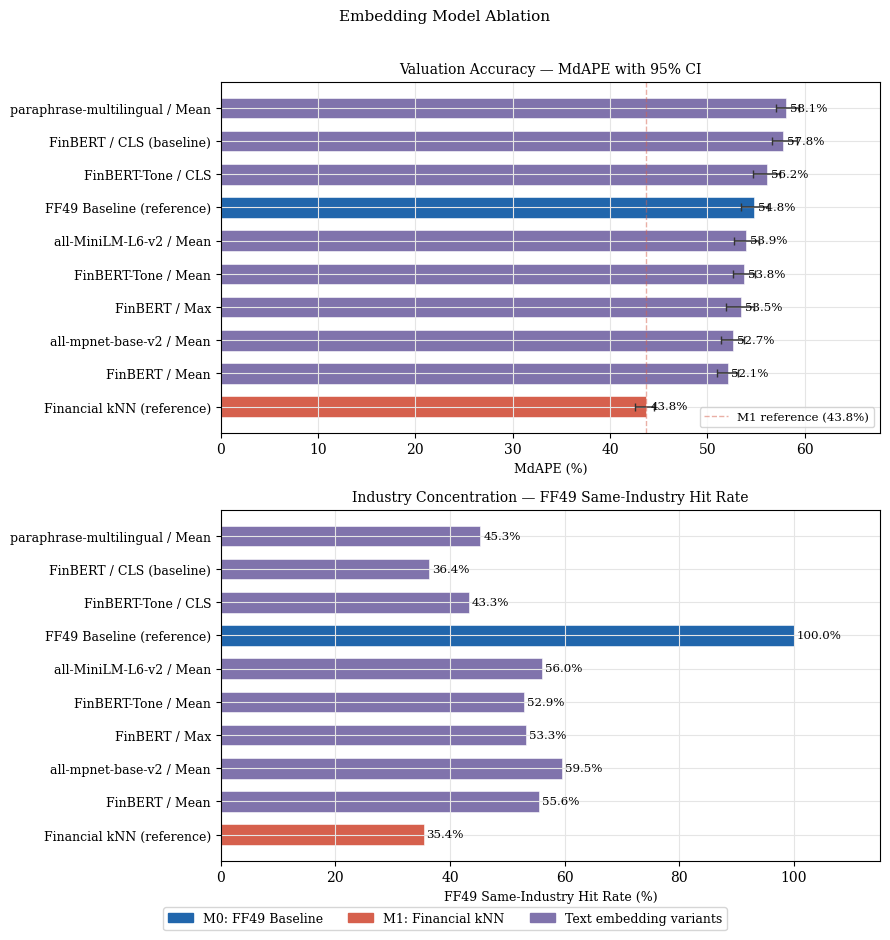

Saved: /work/Repo/notebooks/../figures/ablation_mdape.pdf


In [16]:
# Cell 9 — ablation figure: two stacked bar charts
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 9), sharex=False)

plot_df = pd.DataFrame(baseline_rows + ablation_results).reset_index(drop=True)
plot_df = plot_df.sort_values('mdape', ascending=True).reset_index(drop=True)

colors_plot = []
for _, row in plot_df.iterrows():
    if row['config_id'] == 'M0':
        colors_plot.append('#2166ac')
    elif row['config_id'] == 'M1':
        colors_plot.append('#d6604d')
    else:
        colors_plot.append('#8073ac')

x = np.arange(len(plot_df))

# ── Top: MdAPE ────────────────────────────────────────────────────────────────
bars1 = ax1.barh(x, plot_df['mdape']*100,
                 color=colors_plot, height=0.62,
                 edgecolor='white', linewidth=0.4)
ax1.errorbar(
    plot_df['mdape']*100, x,
    xerr=[(plot_df['mdape'] - plot_df['ci_lo'])*100,
          (plot_df['ci_hi'] - plot_df['mdape'])*100],
    fmt='none', color='#333333', capsize=3, linewidth=1.1
)
for bar, val in zip(bars1, plot_df['mdape']*100):
    ax1.text(val + 0.4, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=8.5)

m1_mdape = plot_df[plot_df['config_id']=='M1']['mdape'].values[0]*100
ax1.axvline(m1_mdape, color='#d6604d', linewidth=1,
            linestyle='--', alpha=0.5, label=f'M1 reference ({m1_mdape:.1f}%)')
ax1.set_yticks(x)
ax1.set_yticklabels(plot_df['label'], fontsize=9)
ax1.set_xlabel('MdAPE (%)', fontsize=9)
ax1.set_xlim(0, plot_df['ci_hi'].max()*100 * 1.14)
ax1.set_title('Valuation Accuracy — MdAPE with 95% CI', fontsize=10)
ax1.legend(fontsize=8.5, loc='lower right')

# ── Bottom: FF49 hit rate ─────────────────────────────────────────────────────
bars2 = ax2.barh(x, plot_df['hit_rate_pct'],
                 color=colors_plot, height=0.62,
                 edgecolor='white', linewidth=0.4)
for bar, val in zip(bars2, plot_df['hit_rate_pct']):
    ax2.text(val + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=8.5)

ax2.set_yticks(x)
ax2.set_yticklabels(plot_df['label'], fontsize=9)
ax2.set_xlabel('FF49 Same-Industry Hit Rate (%)', fontsize=9)
ax2.set_xlim(0, 115)
ax2.set_title('Industry Concentration — FF49 Same-Industry Hit Rate', fontsize=10)

# ── Shared legend ─────────────────────────────────────────────────────────────
legend_elements = [
    mpatches.Patch(color='#2166ac', label='M0: FF49 Baseline'),
    mpatches.Patch(color='#d6604d', label='M1: Financial kNN'),
    mpatches.Patch(color='#8073ac', label='Text embedding variants'),
]
fig.legend(handles=legend_elements, loc='lower center',
           ncol=3, bbox_to_anchor=(0.5, -0.02), fontsize=9)

plt.suptitle('Embedding Model Ablation', fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / 'ablation_mdape.pdf', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES / 'ablation_mdape.pdf'}")

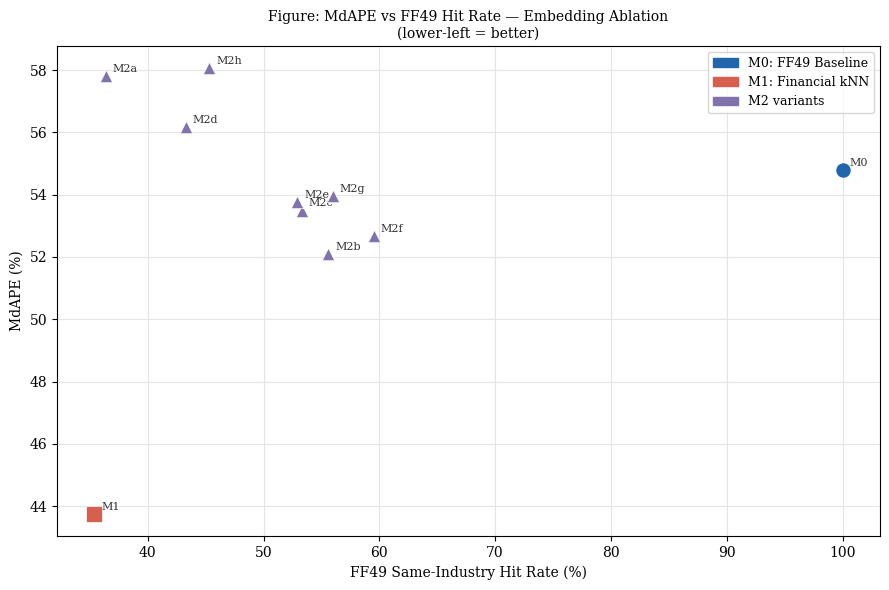

Saved: /work/Repo/notebooks/../figures/ablation_scatter.pdf


In [15]:
# Cell 10 — MdAPE vs hit rate scatter
fig, ax = plt.subplots(figsize=(9, 6))

for _, row in plot_df.iterrows():
    if row['config_id'] == 'M0':
        color, marker, size = '#2166ac', 'o', 120
    elif row['config_id'] == 'M1':
        color, marker, size = '#d6604d', 's', 120
    else:
        color, marker, size = '#8073ac', '^', 80

    ax.scatter(row['hit_rate_pct'], row['mdape']*100,
               color=color, marker=marker, s=size,
               edgecolors='white', linewidth=0.5, zorder=3)
    ax.annotate(row['config_id'],
                (row['hit_rate_pct'], row['mdape']*100),
                textcoords='offset points', xytext=(5, 3),
                fontsize=8, color='#333333')

ax.set_xlabel('FF49 Same-Industry Hit Rate (%)')
ax.set_ylabel('MdAPE (%)')
ax.set_title('Figure: MdAPE vs FF49 Hit Rate — Embedding Ablation\n'
             '(lower-left = better)', fontsize=10)

legend_elements = [
    mpatches.Patch(color='#2166ac', label='M0: FF49 Baseline'),
    mpatches.Patch(color='#d6604d', label='M1: Financial kNN'),
    mpatches.Patch(color='#8073ac', label='M2 variants'),
]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.savefig(FIGURES / 'ablation_scatter.pdf', dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES / 'ablation_scatter.pdf'}")


In [16]:
# Cell 11 — save ablation results
abl_df['run_date'] = pd.Timestamp.now().strftime('%Y-%m-%d')
out_path = DATA_RESULTS / 'ablation_results.csv'
abl_df.to_csv(out_path, index=False)
print(f"Saved: {out_path}")

print()
print("=" * 65)
print("ABLATION SUMMARY")
print("=" * 65)
best = abl_df.iloc[0]
print(f"  Best configuration : {best['config_id']} — {best['label']}")
print(f"  Best MdAPE         : {best['mdape']*100:.2f}%")
print(f"  vs FinBERT/CLS     : {(abl_df[abl_df['config_id']=='M2a']['mdape'].values[0] - best['mdape'])*100:+.2f}pp")
print(f"  vs M1 Financial    : {(0.4442 - best['mdape'])*100:+.2f}pp")
print()
print("  Recommendation:")
if best['config_id'] != 'M2a':
    print(f"  Consider replacing FinBERT/CLS with {best['label']}")
    print(f"  for M2 and M3 — re-run N8 and N9 with best config.")
else:
    print(f"  FinBERT/CLS is already optimal — no change needed.")


Saved: /work/Repo/notebooks/../data/results/ablation_results.csv

ABLATION SUMMARY
  Best configuration : M2b — FinBERT / Mean
  Best MdAPE         : 52.08%
  vs FinBERT/CLS     : +5.73pp
  vs M1 Financial    : -7.66pp

  Recommendation:
  Consider replacing FinBERT/CLS with FinBERT / Mean
  for M2 and M3 — re-run N8 and N9 with best config.
